# 3D Wireframe Visualization with Color Zones

This notebook creates a 3D wireframe plot with:
- Parallel cosine curves as the surface data
- Different colors for lines in different directions
- Color change at 60% through the z-axis (horizontal plane division)

In [34]:
import matplotlib
matplotlib.use("QtAgg")
import numpy as np
import matplotlib.pyplot as plt

# Enable interactive mode for matplotlib
%matplotlib widget

In [35]:
# Generate data for parallel cosine curves with more diverse shapes
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Amplitude scaling factor: starts small on left, grows toward right
# Maps X from [-2, 2] to [0.3, 1.0]
amplitude_scale = 0.3 + 0.7 * (X - x.min()) / (x.max() - x.min())

# Create cosine curves with amplitude that grows along X
Z = amplitude_scale * (
    np.cos(2 * np.pi * X) * (1 + 0.3 * Y)
    + 0.6 * np.cos(1.5 * np.pi * Y + 0.5 * X)
    + 0.3 * np.sin(3 * X * Y)
)

print(f"Data shapes - X: {X.shape}, Y: {Y.shape}, Z: {Z.shape}")
print(f"Z range: {Z.min():.2f} to {Z.max():.2f}")
print(
    f"Amplitude scale range: {amplitude_scale.min():.2f} to {amplitude_scale.max():.2f}"
)

Data shapes - X: (100, 100), Y: (100, 100), Z: (100, 100)
Z range: -1.77 to 2.16
Amplitude scale range: 0.30 to 1.00


In [ ]:
def depth_sort_segments(segments, colors, ax):
    """Sort segments by distance from camera (back-to-front)."""
    elev = np.deg2rad(ax.elev)
    azim = np.deg2rad(ax.azim)

    # Camera direction vector (pointing toward the camera)
    cam_dir = np.array(
        [np.cos(elev) * np.cos(azim), np.cos(elev) * np.sin(azim), np.sin(elev)]
    )

    # Compute centroid of each segment and project onto camera direction
    centroids = segments.mean(axis=1)
    depths = centroids @ cam_dir

    # Sort back-to-front (farthest first, so they get drawn first/behind)
    sort_idx = np.argsort(depths)

    return segments[sort_idx], colors[sort_idx]


In [ ]:
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import numpy as np



def plot_data(
    X,
    Y,
    Z,
    z_split_pct=0.6,
    cmap_x_below=LinearSegmentedColormap.from_list("custom", ["#00BFFF", "#0000CD"]),
    cmap_x_above=LinearSegmentedColormap.from_list("custom", ["#FFD700", "#DC143C"]),
    cmap_y_below=LinearSegmentedColormap.from_list("custom", ["#7FFF00", "#006400"]),
    cmap_y_above=LinearSegmentedColormap.from_list("custom", ["#FFA07A", "#FF4500"]),
    enable_depth_sort=True,
    line_width=1.5,
):
    """
    Create a 3D wireframe plot with color zones split at a percentage of the z-axis.

    - X-direction lines: color varies with X position, hue varies with Z direction
    - Y-direction lines: color varies with Y position, hue varies with Z direction
    - Color changes at z_split_pct along the z-axis

    Parameters:
        X, Y, Z: 2D arrays from meshgrid defining the surface
        z_split_pct: percentage (0-1) along z-axis where color changes (default 0.6)
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Calculate the z-axis split value and ranges
    z_min, z_max = Z.min(), Z.max()
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()
    z_split_val = z_min + z_split_pct * (z_max - z_min)

    print(f"Z-axis range: {z_min:.2f} to {z_max:.2f}")
    print(f"{z_split_pct * 100:.0f}% split point: z = {z_split_val:.2f}")

    # Pre-calculate ranges (avoid division by zero)
    x_range = x_max - x_min if x_max > x_min else 1.0
    y_range = y_max - y_min if y_max > y_min else 1.0

    def process_x_direction_segments(X_arr, Y_arr, Z_arr):
        """
        Process all X-direction segments.
        Color varies with X position.
        """
        # X-direction: shape (rows, cols) -> segments along cols
        x0 = X_arr[:, :-1].ravel()
        x1 = X_arr[:, 1:].ravel()
        y0 = Y_arr[:, :-1].ravel()
        y1 = Y_arr[:, 1:].ravel()
        z0 = Z_arr[:, :-1].ravel()
        z1 = Z_arr[:, 1:].ravel()

        n_segments = len(x0)

        # Vectorized threshold checking
        below_0 = z0 < z_split_val
        below_1 = z1 < z_split_val
        same_side = below_0 == below_1
        cross_mask = ~same_side

        # Count segments (crossing segments produce 2 each)
        n_cross = np.sum(cross_mask)
        n_same = n_segments - n_cross
        total_output = n_same + 2 * n_cross

        # Preallocate output arrays
        segments = np.empty((total_output, 2, 3), dtype=np.float64)
        colors = np.empty((total_output, 4), dtype=np.float64)

        # Process same-side segments
        if n_same > 0:
            same_idx = np.where(same_side)[0]
            is_below = below_0[same_idx]

            # Compute t values based on X position
            x_mid = (x0[same_idx] + x1[same_idx]) / 2
            t_x = (x_mid - x_min) / x_range

            # Get colors from appropriate colormaps
            colors_below = cmap_x_below(t_x)
            colors_above = cmap_x_above(t_x)
            same_colors = np.where(is_below[:, np.newaxis], colors_below, colors_above)

            # Build segments
            segments[:n_same, 0, 0] = x0[same_idx]
            segments[:n_same, 0, 1] = y0[same_idx]
            segments[:n_same, 0, 2] = z0[same_idx]
            segments[:n_same, 1, 0] = x1[same_idx]
            segments[:n_same, 1, 1] = y1[same_idx]
            segments[:n_same, 1, 2] = z1[same_idx]
            colors[:n_same] = same_colors

        # Process crossing segments
        if n_cross > 0:
            cross_idx = np.where(cross_mask)[0]
            x0_c, x1_c = x0[cross_idx], x1[cross_idx]
            y0_c, y1_c = y0[cross_idx], y1[cross_idx]
            z0_c, z1_c = z0[cross_idx], z1[cross_idx]
            below_0_c = below_0[cross_idx]

            # Calculate crossing points
            t = (z_split_val - z0_c) / (z1_c - z0_c)
            x_cross = x0_c + t * (x1_c - x0_c)
            y_cross = y0_c + t * (y1_c - y0_c)

            # Compute t values for X position
            t_x1 = ((x0_c + x_cross) / 2 - x_min) / x_range
            t_x2 = ((x_cross + x1_c) / 2 - x_min) / x_range

            # First sub-segment colors
            colors_1_below = cmap_x_below(t_x1)
            colors_1_above = cmap_x_above(t_x1)
            cross_colors_1 = np.where(
                below_0_c[:, np.newaxis], colors_1_below, colors_1_above
            )

            # Second sub-segment colors (opposite side)
            colors_2_below = cmap_x_below(t_x2)
            colors_2_above = cmap_x_above(t_x2)
            cross_colors_2 = np.where(
                ~below_0_c[:, np.newaxis], colors_2_below, colors_2_above
            )

            # Build crossing segments
            base_idx = n_same
            for i in range(n_cross):
                idx1 = base_idx + 2 * i
                idx2 = base_idx + 2 * i + 1

                segments[idx1, 0] = [x0_c[i], y0_c[i], z0_c[i]]
                segments[idx1, 1] = [x_cross[i], y_cross[i], z_split_val]
                colors[idx1] = cross_colors_1[i]

                segments[idx2, 0] = [x_cross[i], y_cross[i], z_split_val]
                segments[idx2, 1] = [x1_c[i], y1_c[i], z1_c[i]]
                colors[idx2] = cross_colors_2[i]

        return segments, colors

    def process_y_direction_segments(X_arr, Y_arr, Z_arr):
        """
        Process all Y-direction segments.
        Color varies with Y position.
        """
        # Y-direction: shape (rows, cols) -> segments along rows
        x0 = X_arr[:-1, :].ravel()
        x1 = X_arr[1:, :].ravel()
        y0 = Y_arr[:-1, :].ravel()
        y1 = Y_arr[1:, :].ravel()
        z0 = Z_arr[:-1, :].ravel()
        z1 = Z_arr[1:, :].ravel()

        n_segments = len(x0)

        # Vectorized threshold checking
        below_0 = z0 < z_split_val
        below_1 = z1 < z_split_val
        same_side = below_0 == below_1
        cross_mask = ~same_side

        # Count segments (crossing segments produce 2 each)
        n_cross = np.sum(cross_mask)
        n_same = n_segments - n_cross
        total_output = n_same + 2 * n_cross

        # Preallocate output arrays
        segments = np.empty((total_output, 2, 3), dtype=np.float64)
        colors = np.empty((total_output, 4), dtype=np.float64)

        # Process same-side segments
        if n_same > 0:
            same_idx = np.where(same_side)[0]
            is_below = below_0[same_idx]

            # Compute t values based on Y position
            y_mid = (y0[same_idx] + y1[same_idx]) / 2
            t_y = (y_mid - y_min) / y_range

            # Get colors from appropriate colormaps
            colors_below = cmap_y_below(t_y)
            colors_above = cmap_y_above(t_y)
            same_colors = np.where(is_below[:, np.newaxis], colors_below, colors_above)

            # Build segments
            segments[:n_same, 0, 0] = x0[same_idx]
            segments[:n_same, 0, 1] = y0[same_idx]
            segments[:n_same, 0, 2] = z0[same_idx]
            segments[:n_same, 1, 0] = x1[same_idx]
            segments[:n_same, 1, 1] = y1[same_idx]
            segments[:n_same, 1, 2] = z1[same_idx]
            colors[:n_same] = same_colors

        # Process crossing segments
        if n_cross > 0:
            cross_idx = np.where(cross_mask)[0]
            x0_c, x1_c = x0[cross_idx], x1[cross_idx]
            y0_c, y1_c = y0[cross_idx], y1[cross_idx]
            z0_c, z1_c = z0[cross_idx], z1[cross_idx]
            below_0_c = below_0[cross_idx]

            # Calculate crossing points
            t = (z_split_val - z0_c) / (z1_c - z0_c)
            x_cross = x0_c + t * (x1_c - x0_c)
            y_cross = y0_c + t * (y1_c - y0_c)

            # Compute t values for Y position
            t_y1 = ((y0_c + y_cross) / 2 - y_min) / y_range
            t_y2 = ((y_cross + y1_c) / 2 - y_min) / y_range

            # First sub-segment colors
            colors_1_below = cmap_y_below(t_y1)
            colors_1_above = cmap_y_above(t_y1)
            cross_colors_1 = np.where(
                below_0_c[:, np.newaxis], colors_1_below, colors_1_above
            )

            # Second sub-segment colors (opposite side)
            colors_2_below = cmap_y_below(t_y2)
            colors_2_above = cmap_y_above(t_y2)
            cross_colors_2 = np.where(
                ~below_0_c[:, np.newaxis], colors_2_below, colors_2_above
            )

            # Build crossing segments
            base_idx = n_same
            for i in range(n_cross):
                idx1 = base_idx + 2 * i
                idx2 = base_idx + 2 * i + 1

                segments[idx1, 0] = [x0_c[i], y0_c[i], z0_c[i]]
                segments[idx1, 1] = [x_cross[i], y_cross[i], z_split_val]
                colors[idx1] = cross_colors_1[i]

                segments[idx2, 0] = [x_cross[i], y_cross[i], z_split_val]
                segments[idx2, 1] = [x1_c[i], y1_c[i], z1_c[i]]
                colors[idx2] = cross_colors_2[i]

        return segments, colors

    # Process X-direction and Y-direction segments
    x_segments, x_colors = process_x_direction_segments(X, Y, Z)
    y_segments, y_colors = process_y_direction_segments(X, Y, Z)

    # Combine all segments
    all_segments = np.concatenate([x_segments, y_segments], axis=0)
    all_colors = np.concatenate([x_colors, y_colors], axis=0)

    # Apply depth sorting to the first/static renders
    sorted_segments, sorted_colors = depth_sort_segments(all_segments, all_colors, ax)

    # Create a single Line3DCollection for all segments
    line_collection = Line3DCollection(
        sorted_segments, colors=sorted_colors, linewidths=line_width
    )
    ax.add_collection3d(line_collection)

    # Set up dynamic depth sorting on view changes
    if enable_depth_sort:

        def on_draw(_event):
            nonlocal all_segments, all_colors
            sorted_segs, sorted_cols = depth_sort_segments(all_segments, all_colors, ax)
            line_collection.set_segments(sorted_segs)
            line_collection.set_colors(sorted_cols)

        fig.canvas.mpl_connect("draw_event", on_draw)

    # Set axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)

    # Add labels and title
    ax.set_xlabel("X Axis", fontsize=12)
    ax.set_ylabel("Y Axis", fontsize=12)
    ax.set_zlabel("Z Axis", fontsize=12)
    ax.set_title(
        f"3D Wireframe: Position Gradients + Z-Region Hues\nColor split at {z_split_pct * 100:.0f}% Z-axis",
        fontsize=14,
        pad=20,
    )

    # Add a horizontal plane indicator at the split point (using cached values)
    verts = [[(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)]]
    plane = PolyCollection(verts, alpha=0.15, facecolors="gray", edgecolors="none")
    ax.add_collection3d(plane, zs=z_split_val, zdir="z")

    # Add legend
    legend_elements = [
        Line2D(
            [0],
            [0],
            color=cmap_x_below(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_x_below(0.6),
            label="X-lines below",
        ),
        Line2D(
            [0],
            [0],
            color=cmap_x_above(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_x_above(0.6),
            label="X-lines above",
        ),
        Line2D(
            [0],
            [0],
            color=cmap_y_below(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_y_below(0.6),
            label="Y-lines below",
        ),
        Line2D(
            [0],
            [0],
            color=cmap_y_above(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_y_above(0.6),
            label="Y-lines above",
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            lw=2,
            alpha=0.3,
            label=f"{z_split_pct * 100:.0f}% Z split plane",
        ),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

    # Set viewing angle
    ax.view_init(elev=25, azim=45)

    # display the plot
    plt.tight_layout()
    plt.show()

    # Check for QtAgg backend
    backend = matplotlib.get_backend()
    print(f" Using backend: {backend}")

    # return figure and axis references for any further manipulation
    return fig, ax

print("plot_data function defined.")

plot_data function defined.


Z-axis range: -1.77 to 2.16
60% split point: z = 0.59


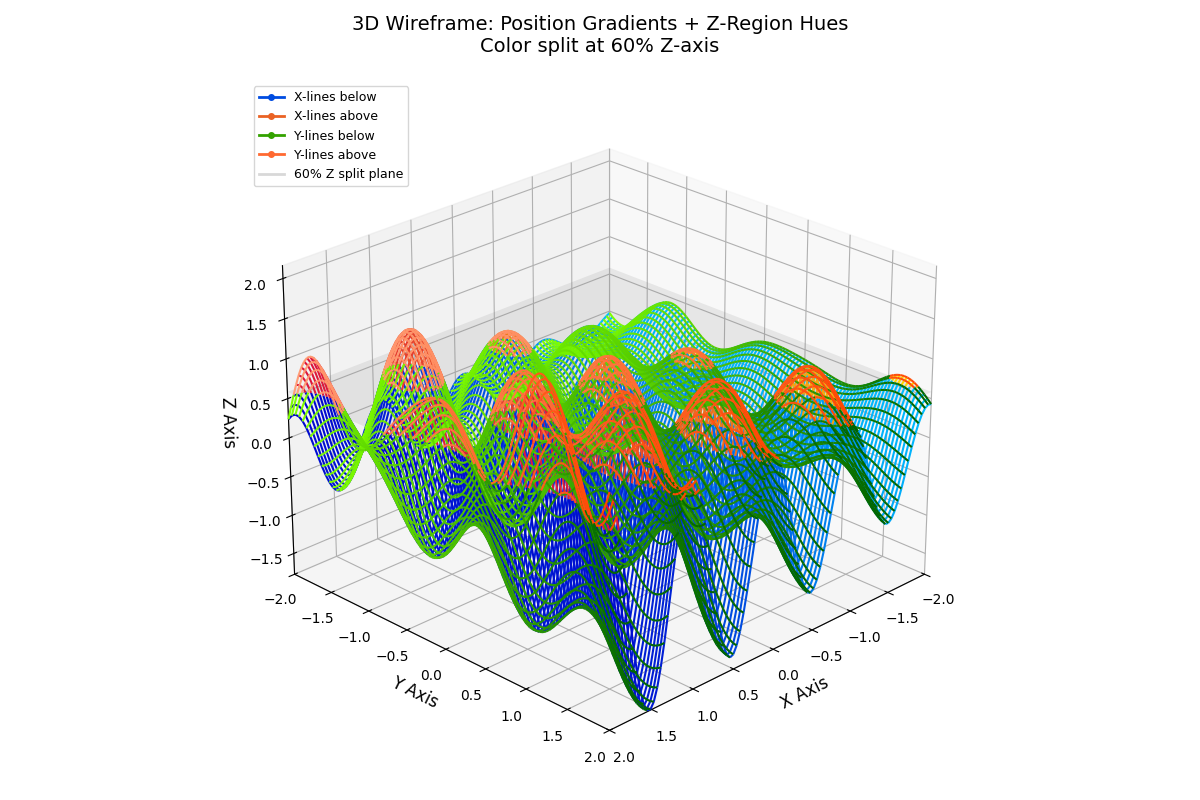

 Using backend: widget
Plot displayed.


In [37]:
# Call the plotting function with our data
fig, ax = plot_data(X, Y, Z)

print("Plot displayed.")